# Figure S6C

In [ ]:
%%bash
### download votu rep FAA file
# wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/votus_hq_plus.faa.gz

In [ ]:
%%bash
### calculate protein similarity for votu reps
# micromamba activate blast

# diamond \
#     makedb \
#     --threads 32 \
#     --in votus_hq_plus.faa.gz \
#     -d votus_hq_plus_diamonddb

# diamond \
#     blastp \
#     --masking none \
#     -k0 \
#     -e 1e-3 \
#     --very-sensitive \
#     --query votus_hq_plus.faa.gz \
#     --db votus_hq_plus_diamonddb \
#     --threads 32 \
#     --outfmt 6 \
#     --out votus_hq_plus.diamond_blastp.tsv

# /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/bin/uhvdb_selfscore.py \
#     --input votus_hq_plus.diamond_blastp.tsv \
#     --output votus_hq_plus.selfscore.tsv

# /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/bin/uhvdb_normscore.py \
#     --input votus_hq_plus.diamond_blastp.tsv \
#     --selfscore votus_hq_plus.selfscore.tsv \
#     --threads 32 \
#     --output votus_hq_plus.normscore.tsv

In [ ]:
### Filter protein similarity for family and genus levels
import polars as pl

# filter norm score file at each taxonomic level
normscore = (
    pl.read_csv('votus_hq_plus.normscore.tsv', separator='\t', columns=['query', 'reference', 'norm_score'])
        .filter(pl.col('norm_score') >= 5.5)
)

normscore.write_csv('votus_hq_plus.normscore_family.filtered.tsv', separator='\t', include_header=False)
# normscore.filter(pl.col('norm_score') >= 32).write_csv('votus_hq_plus.normscore_subfamily.filtered.tsv', separator='\t', include_header=False)
normscore.filter(pl.col('norm_score') >= 65).write_csv('votus_hq_plus.normscore_genus.filtered.tsv', separator='\t', include_header=False)
# normscore.filter(pl.col('norm_score') >= 80).write_csv('votus_hq_plus.normscore_subgenus.filtered.tsv', separator='\t', include_header=False)

In [ ]:
### create a file with list of ids for UHGV HQ+ vOTU reps
# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv

import polars as pl

(
    pl.read_csv('uhgv_metadata.tsv', ignore_errors=True, separator='\t')
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident') &
            (pl.col('votu_representative') == 'Yes')
        )[['uhgv_genome']]
        .write_csv('votus_hq_plus.ids.txt', include_header=False)
)

In [ ]:
%%bash
### clusters subsets 
# for rep in {1..5}; do
#     for subset in "1000" "5000" "10000" "20000"; do
#         mkdir -p aai_subset_${subset}/

#         shuf --random-source=<(yes $rep) -n $subset \
#             votus_hq_plus.ids.txt \
#             > aai_subset_${subset}/votus_hq_plus.subset${subset}_rep${rep}_ids.tsv

#         for rank in "family" "genus"; do
#             csvtk join --tabs \
#                 -f "1;1" \
#                 votus_hq_plus.normscore_${rank}.filtered.tsv \
#                 aai_subset_${subset}/votus_hq_plus.subset${subset}_rep${rep}_ids.tsv | \
#             csvtk join --tabs \
#                 -f "2;1" \
#                 - aai_subset_${subset}/votus_hq_plus.subset${subset}_rep${rep}_ids.tsv \
#                 --out-file aai_subset_${subset}/votus_hq_plus.normscore_${rank}.subset${subset}_rep${rep}.tsv

#             micromamba run -n mcl \
#                 mcl \
#                     aai_subset_${subset}/votus_hq_plus.normscore_${rank}.subset${subset}_rep${rep}.tsv \
#                     --abc \
#                     -sort revsize \
#                     -te 32 \
#                     -o votus_hq_plus.${rank}.subset${subset}_rep${rep}.mcl

#         done
#     done
# done


In [ ]:
%%bash
### cluster full set
# mkdir -p aai_subset_full/

# cat \
#     votus_hq_plus.ids.txt \
#     > aai_subset_full/votus_hq_plus.subsetfull_ids.tsv

# for rank in "family" "genus"; do
#     micromamba run -n mcl \
#         mcl \
#             votus_hq_plus.normscore_${rank}.filtered.tsv \
#             --abc \
#             -sort revsize \
#             -te 32 \
#             -o votus_hq_plus.${rank}.subsetfull.mcl
# done

In [1]:
### function to load mcl clusters into a DataFrame
def load_mcl_clusters(mcl, seq_id):
    # assign sequences to mcl clusters
    clusters = {}

    cluster_id = 0
    with open(mcl, 'r') as mcl_file:
        for line in mcl_file:
            cluster_id += 1
            for node in line.strip().split():
                clusters[node] = cluster_id

    # assign unclustered sequences to their own cluster
    with open(seq_id, 'r') as seqid_file:
        for line in seqid_file:
            sequence = line.strip()
            if sequence not in clusters:
                cluster_id += 1
                clusters[sequence] = cluster_id

    # convert to a DataFrame
    clusters_df = pl.DataFrame({
        'seq_id': list(clusters.keys()),
        'cluster_id': list(clusters.values())
    })

    return clusters_df

In [2]:
### calculate homogeneity and completeness scores for cluster subsets
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics import v_measure_score
import polars as pl

results = []

subsets = ['1000', '5000', '10000', '20000']

for rep in range(1, 6):
    for i in range(len(subsets)):
        for rank in ['family', 'genus']:
            clusters = load_mcl_clusters(f'votus_hq_plus.{rank}.subset{subsets[i]}_rep{rep}.mcl', f'aai_subset_{subsets[i]}/votus_hq_plus.subset{subsets[i]}_rep{rep}_ids.tsv').sort(pl.col('seq_id'), descending=False)
            multi_seq_clusters = set(clusters.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
            clusters_filt = clusters.filter(pl.col('cluster_id').is_in(multi_seq_clusters))

            clusters_full = load_mcl_clusters(f'votus_hq_plus.{rank}.subsetfull.mcl', 'aai_subset_full/votus_hq_plus.subsetfull_ids.tsv').sort(pl.col('seq_id'), descending=False)

            # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters
            h_score = homogeneity_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

            # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters
            c_score = completeness_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

            # calculate v-measure score
            v_score = v_measure_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

            results.append({
                "subset": subsets[i],
                "replicate": rep,
                "Rank": rank,
                "num_sequences": clusters['seq_id'].n_unique(),
                "Total clusters": clusters['cluster_id'].n_unique(),
                "num_seqs_in_multi_seq_clusters": clusters_filt['seq_id'].n_unique(),
                "Non-singleton clusters": clusters_filt['cluster_id'].n_unique(),
                "homogeneity": h_score,
                "completeness": c_score,
                "v-measure": v_score
            })

            # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters (merging lowers score)
            # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters (splitting lowers score)
            # v-measure: harmonic mean of homogeneity and completeness

            if subsets[i] == '1000' and rep == 1:
                multi_seq_clusters_full = set(clusters_full.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
                clusters_full_filt = clusters_full.filter(pl.col('cluster_id').is_in(multi_seq_clusters_full))

                results.append({
                    "subset": "57514",
                    "replicate": 1,
                    "Rank": rank,
                    "num_sequences": clusters_full['seq_id'].n_unique(),
                    "Total clusters": clusters_full['cluster_id'].n_unique(),
                    "num_seqs_in_multi_seq_clusters": clusters_full_filt['seq_id'].n_unique(),
                    "Non-singleton clusters": clusters_full_filt['cluster_id'].n_unique(),
                    "homogeneity": None,
                    "completeness": None,
                    "v-measure": None
                })

Text(0, 0.5, 'v-Measure score')

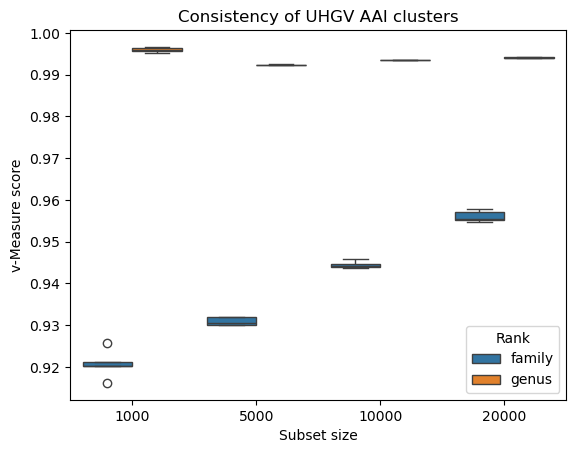

In [3]:
### create boxplot of results
import seaborn as sns
import matplotlib.pyplot as plt

subset_results = (
    pl.from_dicts(results)
        .filter(pl.col("subset") != "57514")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
sns.boxplot(x="subset", y="v-measure", data=subset_results, hue="Rank")
plt.title("Consistency of UHGV AAI clusters")
plt.xlabel("Subset size")
plt.ylabel("v-Measure score")

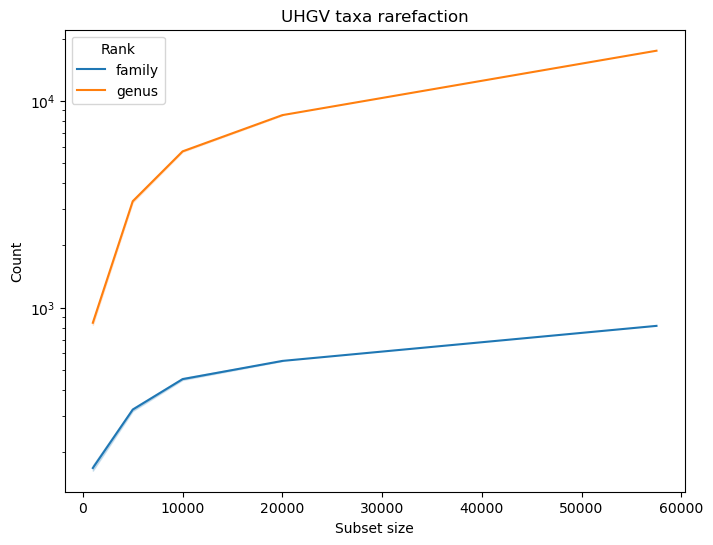

In [ ]:
### create rarefaction of cluster counts
subset_cluster_counts = (
    pl.from_dicts(results)
        .with_columns([pl.col("subset").cast(pl.Int32)])
        .unpivot(index=["subset", "replicate", "Rank"], on=["Total clusters"], variable_name="metric", value_name="value")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
plt.figure(figsize=(8, 6))
sns.lineplot(x="subset", y="value", hue='Rank', data=subset_cluster_counts)
plt.title("UHGV taxa rarefaction")
plt.xlabel("Subset size")
plt.ylabel("Count")
plt.yscale('log')

In [ ]:
### calculate homogeneity and completeness scores for UHVDB clusters vs UHGV
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics import v_measure_score
import polars as pl

# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/votus_metadata_extended.tsv

uhgv_v_uhvdb_results = []

for rank in ['family', 'genus']:
    print(f"Calculating scores for {rank}...\n")

    clusters_full = load_mcl_clusters(f'votus_hq_plus.{rank}.subsetfull.mcl','aai_subset_full/votus_hq_plus.subsetfull_ids.tsv').sort(pl.col('seq_id'), descending=False)

    uhgv_clusters = (
        pl.read_csv('votus_metadata_extended.tsv', separator='\t',
            columns=['uhgv_genome', 'checkv_quality', 'viral_confidence', 'family_name', 'genus_name', 'uhgv_taxonomy']
        )
        .filter(
            (pl.col('uhgv_genome').is_in(clusters_full['seq_id']))
        )
        .with_columns([
            pl.col('uhgv_taxonomy').str.split(';').list[0].str.split('-').list[1].alias('uhgv_family'),
            pl.col('uhgv_taxonomy').str.split(';').list[1].str.split('-').list[1].alias('uhgv_subfamily'),
            pl.col('uhgv_taxonomy').str.split(';').list[2].str.split('-').list[1].alias('uhgv_genus'),
            pl.col('uhgv_taxonomy').str.split(';').list[3].str.split('-').list[1].alias('uhgv_subgenus'),
            pl.col('uhgv_taxonomy').str.split(';').list[4].str.split('-').list[1].alias('uhgv_votu')
        ])
        .sort(pl.col('uhgv_genome'), descending=False)
        [['uhgv_genome', f'uhgv_{rank}']]
    )

    multi_uhgv_clusters = set(uhgv_clusters.group_by(f'uhgv_{rank}').len().filter(pl.col('len') > 1)[f'uhgv_{rank}'])
    uhgv_clusters_filt = uhgv_clusters.filter(pl.col(f'uhgv_{rank}').is_in(multi_uhgv_clusters))

    multi_seq_clusters = set(clusters_full.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
    clusters_full_filt = clusters_full.filter(pl.col('cluster_id').is_in(multi_seq_clusters))

    # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters
    h_score = homogeneity_score(uhgv_clusters[f'uhgv_{rank}'], clusters_full['cluster_id'])

    # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters
    c_score = completeness_score(uhgv_clusters[f'uhgv_{rank}'], clusters_full['cluster_id'])

    # calculate v-measure score
    v_score = v_measure_score(uhgv_clusters[f'uhgv_{rank}'], clusters_full['cluster_id'])

    uhgv_v_uhvdb_results.append({
        "Rank": rank,
        "num_uhgv_clusters": uhgv_clusters[f'uhgv_{rank}'].n_unique(),
        "num_multi_seq_uhgv_clusters": uhgv_clusters_filt[f'uhgv_{rank}'].n_unique(),
        "num_seqs_in_multi_seq_uhgv_clusters": uhgv_clusters_filt.shape[0],
        "num_uhvdb_clusters": clusters_full['cluster_id'].n_unique(),
        "num_multi_seq_uhvdb_clusters": clusters_full_filt['cluster_id'].n_unique(),
        "num_seqs_in_multi_seq_uhvdb_clusters": clusters_full_filt.shape[0],
        "h_score": h_score,
        "c_score": c_score,
        "v_score": v_score
    })

Calculating scores for family...

Calculating scores for genus...



In [17]:
pl.from_dicts(uhgv_v_uhvdb_results)
# family completeness = 0.784 (lots of UHGV family-level clusters split without fragmented seqs)

Rank,num_uhgv_clusters,num_multi_seq_uhgv_clusters,num_seqs_in_multi_seq_uhgv_clusters,num_uhvdb_clusters,num_multi_seq_uhvdb_clusters,num_seqs_in_multi_seq_uhvdb_clusters,h_score,c_score,v_score
str,i64,i64,i64,i64,i64,i64,f64,f64,f64
"""family""",454,361,57421,815,745,57444,0.971085,0.784003,0.867573
"""genus""",19782,5914,43646,17455,6907,46966,0.984906,0.986934,0.985919
